In [1]:
import sys, json, re, time, os
from pathlib import Path
import numpy as np
import pandas as pd
from galois import GF2
from randextract import ToeplitzHashing

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR / 'scripts'))

import deploy_fabric as deploy
from qne.cascade import Key, ORIGINAL, Reconciliation, MockClassicalSession, SDCFaultInjector
from qne.cascade.key import key_from_sifted_json
from qne.cascade.sweep_utils import (
    run_condition_sweep, summarize_outcomes,
    run_real_channel_trial, run_real_channel_reconciliation_trial,
    collect_key_pairs,
)

SLICE_NAME = 'qfabric-bb84-2'
fablib = deploy.get_fablib()
slice_obj = fablib.get_slice(name=SLICE_NAME)
slice_obj.show()

alice = slice_obj.get_node("alice")
bob = slice_obj.get_node("bob")
bob_ip = "10.10.1.2"

probs_th = [0.5, 0.3, 0.1, 0.05, 0.03, 0.01, 0.003, 0.001]
probs_recon = [0.3, 0.1, 0.03, 0.01, 0.003, 0.001]

MOCK_N_RUNS = 50          # cheap, local -- fine at full density per key
REALCHANNEL_N_RUNS = 20    # real FABRIC trials -- kept low since this now multiplies by 5 keys

print("Setup complete: slice, nodes, imports ready")

Orchestrator,orchestrator.fabric-testbed.net
Credential Manager,cm.fabric-testbed.net
Core API,uis.fabric-testbed.net
Artifact Manager,artifacts.fabric-testbed.net
CEPH Manager,https://ceph-mgr.fabric-testbed.net
Token File,/home/fabric/work/fabric_config/id_token.json
Project ID,24f4c8f3-e872-492a-9a83-b48211a91966
Bastion Host,bastion.fabric-testbed.net
Bastion Username,audreyf_0000527467
Bastion Private Key File,/home/fabric/work/fabric_config/fabric_bastion_key
Slice Public Key File,/home/fabric/work/fabric_config/slice_key.pub


User: audreyf@illinois.edu bastion key is valid!
Configuration is valid


ID,900e9b70-47f3-4394-a831-e522acb47878
Name,qfabric-bb84-2
Lease Expiration (UTC),2026-09-01 21:17:14 +0000
Lease Start (UTC),2026-08-11 21:17:14 +0000
Project ID,24f4c8f3-e872-492a-9a83-b48211a91966
State,StableOK
Email,audreyf@illinois.edu
UserId,8616dd8c-5b61-45db-84bb-791c21e82a89


Setup complete: slice, nodes, imports ready


In [2]:
import pandas as pd
import numpy as np
from scipy import stats

fault_files_real = {
    "toeplitz": "sdc_realchannel_toeplitz_allkeys.csv",
    "final_key": "sdc_realchannel_finalkey_allkeys.csv",
    "reconciliation": "sdc_realchannel_reconciliation_allkeys.csv",
    "verify_digest": "sdc_realchannel_verifydigest_allkeys.csv",
}

real_dfs = []
for fault_type, fname in fault_files_real.items():
    path = PROJECT_DIR / "results" / fname
    if path.exists():
        df = pd.read_csv(str(path))
        if "fault_type" not in df.columns:
            df["fault_type"] = fault_type
        df["source"] = "real"
        real_dfs.append(df)
real_df = pd.concat(real_dfs, ignore_index=True)
real_df["mismatch"] = real_df["keys_match"].eq(False)

mock_df = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_mock_allkeys_withverification.csv"))
mock_df["source"] = "mock"
mock_df["mismatch"] = (~mock_df["keys_match"].astype("boolean")).fillna(False)

In [3]:
def summarize(df, group_cols):
    g = df.groupby(group_cols)["mismatch"]
    out = g.agg(mean_mismatch="mean", std_mismatch="std", n="count").reset_index()
    return out

real_summary = summarize(real_df, ["fault_type", "length_mode", "prob"])
mock_summary = summarize(mock_df, ["fault_type", "length_mode", "prob"])

print("=== REAL: mean mismatch rate (stdev) by fault/mode/prob ===")
print(real_summary.to_string(index=False))
print("\n=== MOCK: mean mismatch rate (stdev) by fault/mode/prob ===")
print(mock_summary.to_string(index=False))

=== REAL: mean mismatch rate (stdev) by fault/mode/prob ===
    fault_type length_mode  prob  mean_mismatch  std_mismatch   n
     final_key  asymptotic 0.001           0.04      0.196946 100
     final_key  asymptotic 0.003           0.04      0.196946 100
     final_key  asymptotic 0.010           0.04      0.196946 100
     final_key  asymptotic 0.030           0.04      0.196946 100
     final_key  asymptotic 0.050           0.08      0.272660 100
     final_key  asymptotic 0.100           0.18      0.386123 100
     final_key  asymptotic 0.300           0.36      0.482418 100
     final_key  asymptotic 0.500           0.49      0.502418 100
     final_key placeholder 0.001           0.04      0.196946 100
     final_key placeholder 0.003           0.04      0.196946 100
     final_key placeholder 0.010           0.04      0.196946 100
     final_key placeholder 0.030           0.04      0.196946 100
     final_key placeholder 0.050           0.08      0.272660 100
     final_key p

In [4]:
def two_proportion_ztest(successes1, n1, successes2, n2):
    p1, p2 = successes1 / n1, successes2 / n2
    p_pool = (successes1 + successes2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    if se == 0:
        return np.nan, np.nan
    z = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value

print("=== Real vs Mock: two-proportion z-test, per fault/mode/prob ===")
for (fault_type, length_mode, prob), real_g in real_df.groupby(["fault_type", "length_mode", "prob"]):
    mock_g = mock_df[(mock_df["fault_type"] == fault_type) &
                       (mock_df["length_mode"] == length_mode) &
                       (mock_df["prob"] == prob)]
    if len(mock_g) == 0:
        continue
    s1, n1 = real_g["mismatch"].sum(), len(real_g)
    s2, n2 = mock_g["mismatch"].sum(), len(mock_g)
    z, p = two_proportion_ztest(s1, n1, s2, n2)
    sig = "**" if p < 0.05 else ""
    print(f"  {fault_type:<15} {length_mode:<12} prob={prob:<6}: "
          f"real={s1}/{n1}, mock={s2}/{n2}, z={z:.3f}, p={p:.4f} {sig}")

# --- Secondary check: t-test on per-key mismatch rates (real vs mock) ---
print("\n=== Secondary: per-key rate t-test, per fault/mode/prob ===")
for (fault_type, length_mode, prob), _ in real_df.groupby(["fault_type", "length_mode", "prob"]):
    real_rates = real_df[(real_df["fault_type"] == fault_type) &
                           (real_df["length_mode"] == length_mode) &
                           (real_df["prob"] == prob)].groupby("key_index")["mismatch"].mean()
    mock_rates = mock_df[(mock_df["fault_type"] == fault_type) &
                           (mock_df["length_mode"] == length_mode) &
                           (mock_df["prob"] == prob)].groupby("key_index")["mismatch"].mean()
    if len(real_rates) < 2 or len(mock_rates) < 2:
        continue
    t_stat, p_val = stats.ttest_ind(real_rates, mock_rates, equal_var=False)
    print(f"  {fault_type:<15} {length_mode:<12} prob={prob:<6}: t={t_stat:.3f}, p={p_val:.4f}")

=== Real vs Mock: two-proportion z-test, per fault/mode/prob ===
  final_key       asymptotic   prob=0.001 : real=4/100, mock=6/100, z=-0.649, p=0.5164 
  final_key       asymptotic   prob=0.003 : real=4/100, mock=6/100, z=-0.649, p=0.5164 
  final_key       asymptotic   prob=0.01  : real=4/100, mock=6/100, z=-0.649, p=0.5164 
  final_key       asymptotic   prob=0.03  : real=4/100, mock=6/100, z=-0.649, p=0.5164 
  final_key       asymptotic   prob=0.05  : real=8/100, mock=10/100, z=-0.494, p=0.6212 
  final_key       asymptotic   prob=0.1   : real=18/100, mock=19/100, z=-0.182, p=0.8555 
  final_key       asymptotic   prob=0.3   : real=36/100, mock=37/100, z=-0.147, p=0.8832 
  final_key       asymptotic   prob=0.5   : real=49/100, mock=49/100, z=0.000, p=1.0000 
  final_key       placeholder  prob=0.001 : real=4/100, mock=6/100, z=-0.649, p=0.5164 
  final_key       placeholder  prob=0.003 : real=4/100, mock=6/100, z=-0.649, p=0.5164 
  final_key       placeholder  prob=0.01  : real=

  toeplitz        asymptotic   prob=0.05  : t=-0.775, p=0.4655
  toeplitz        asymptotic   prob=0.1   : t=-0.632, p=0.5485
  toeplitz        asymptotic   prob=0.3   : t=-0.338, p=0.7463
  toeplitz        asymptotic   prob=0.5   : t=-0.307, p=0.7677
  toeplitz        placeholder  prob=0.001 : t=-0.577, p=0.5823
  toeplitz        placeholder  prob=0.003 : t=-0.577, p=0.5823
  toeplitz        placeholder  prob=0.01  : t=-0.577, p=0.5823
  toeplitz        placeholder  prob=0.03  : t=-0.577, p=0.5823
  toeplitz        placeholder  prob=0.05  : t=-0.775, p=0.4655
  toeplitz        placeholder  prob=0.1   : t=-0.632, p=0.5485
  toeplitz        placeholder  prob=0.3   : t=-0.338, p=0.7463
  toeplitz        placeholder  prob=0.5   : t=-0.307, p=0.7677


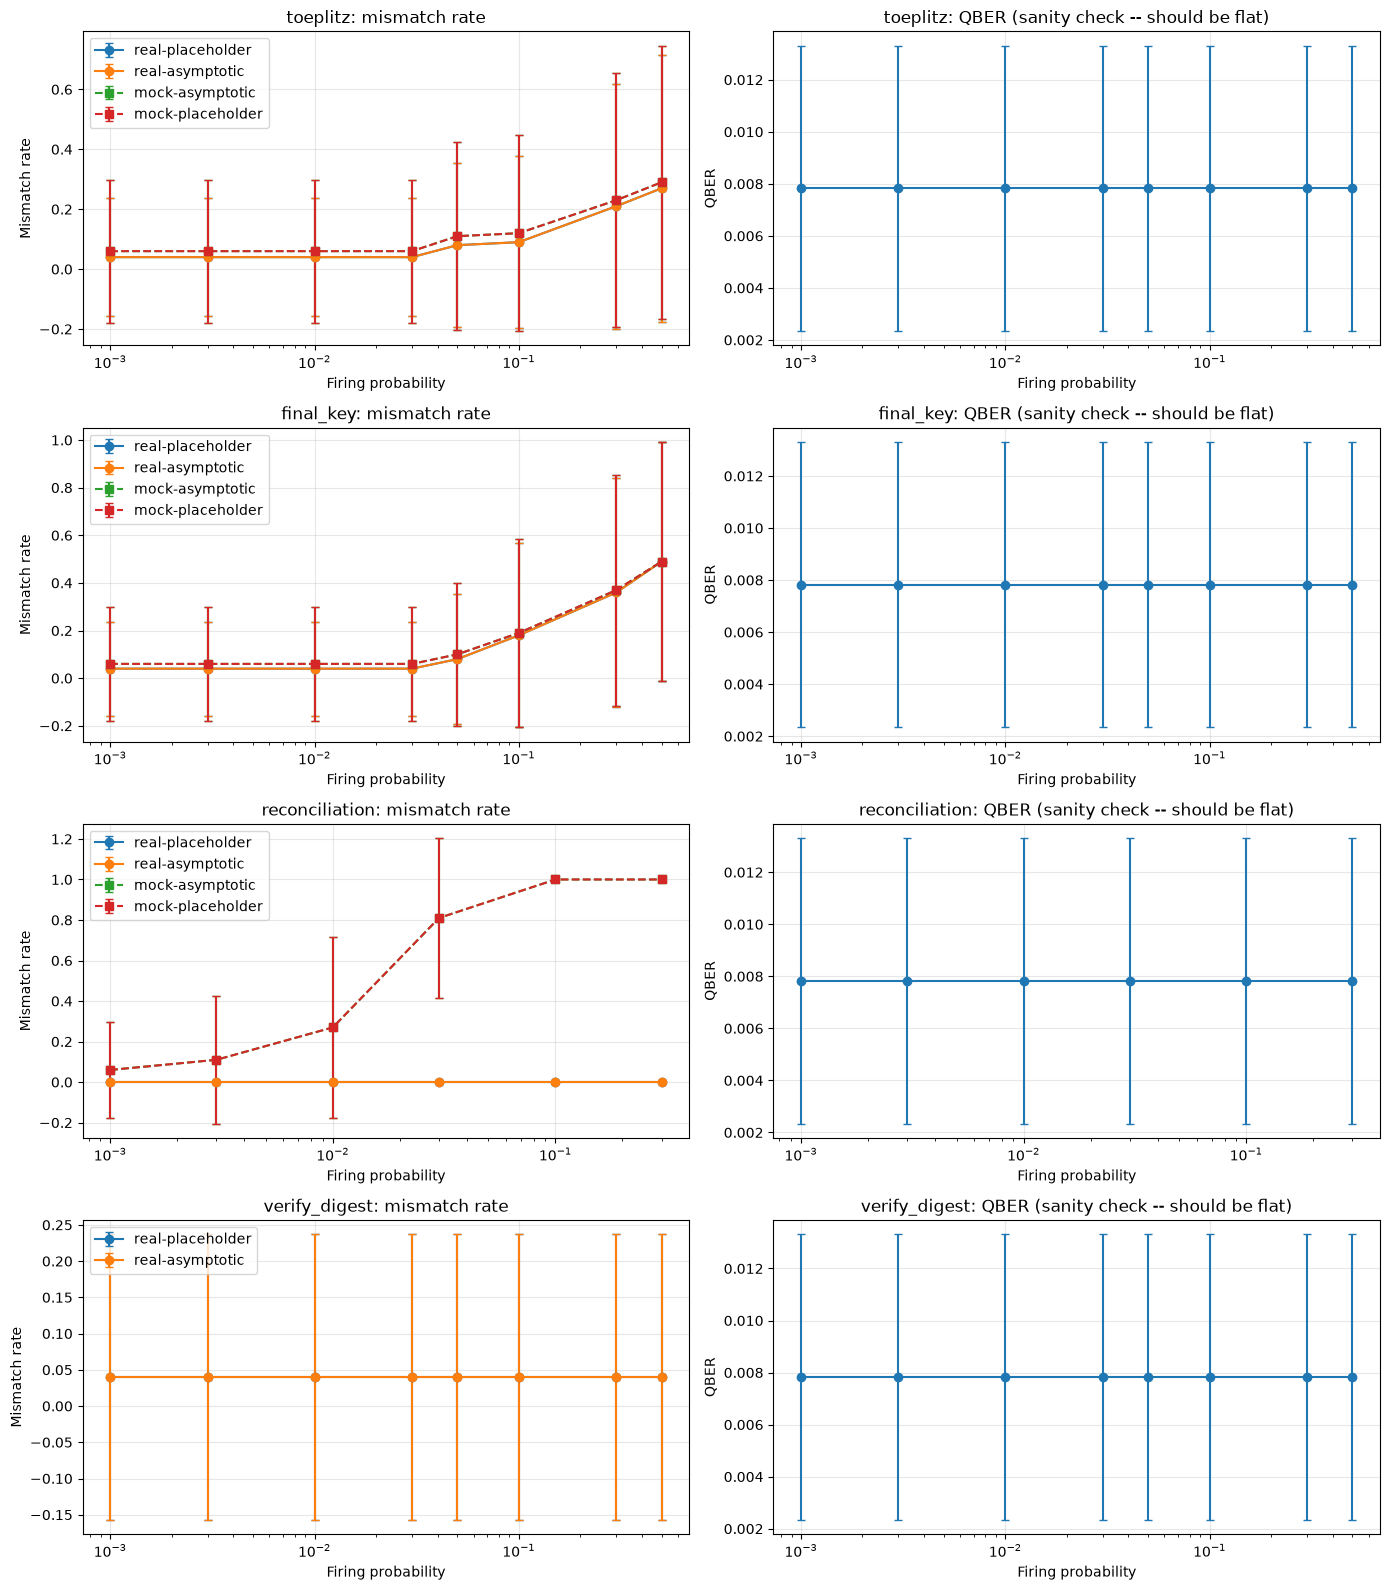

In [5]:
import matplotlib.pyplot as plt

fault_types = real_df["fault_type"].unique()
fig, axes = plt.subplots(len(fault_types), 2, figsize=(14, 4 * len(fault_types)))

for i, fault_type in enumerate(fault_types):
    prob_col = "reconciliation_prob" if fault_type == "reconciliation" else "prob"

    for source, df, style in [("real", real_df, "-o"), ("mock", mock_df, "--s")]:
        sub = df[df["fault_type"] == fault_type]
        for length_mode in sub["length_mode"].unique():
            lm_sub = sub[sub["length_mode"] == length_mode]
            grouped = lm_sub.groupby(prob_col)["mismatch"].agg(["mean", "std"])
            axes[i, 0].errorbar(grouped.index, grouped["mean"], yerr=grouped["std"],
                                   fmt=style, label=f"{source}-{length_mode}", capsize=3)

    axes[i, 0].set_xscale("log")
    axes[i, 0].set_xlabel("Firing probability")
    axes[i, 0].set_ylabel("Mismatch rate")
    axes[i, 0].set_title(f"{fault_type}: mismatch rate")
    axes[i, 0].legend()
    axes[i, 0].grid(alpha=0.3)

    # QBER vs probability (mostly a sanity check -- QBER shouldn't depend on
    # the swept fault probability at all, since faults happen after sifting)
    real_sub = real_df[real_df["fault_type"] == fault_type]
    if "qber" in real_sub.columns:
        grouped_q = real_sub.groupby(prob_col)["qber"].agg(["mean", "std"])
        axes[i, 1].errorbar(grouped_q.index, grouped_q["mean"], yerr=grouped_q["std"],
                               fmt="-o", capsize=3)
    axes[i, 1].set_xscale("log")
    axes[i, 1].set_xlabel("Firing probability")
    axes[i, 1].set_ylabel("QBER")
    axes[i, 1].set_title(f"{fault_type}: QBER (sanity check -- should be flat)")
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_real_vs_mock_comparison.png"), dpi=150)
plt.show()

In [6]:
def compute_abort_metrics(df):
    df = df.copy()
    df["true_abort"] = df["non_convergent"].fillna(False)
    df["false_abort"] = (~df["non_convergent"].fillna(False)) & \
                          (df["verification_passed"] == False) & \
                          (df["keys_match"] == True)
    df["abort"] = df["true_abort"] | (df["verification_passed"] == False)
    return df

real_df = compute_abort_metrics(real_df)
mock_df = compute_abort_metrics(mock_df)

print("=== Abort rate (real): non-convergence + false abort ===")
abort_summary_real = real_df.groupby(["fault_type", "length_mode", "prob"]).agg(
    abort_rate=("abort", "mean"), true_abort_rate=("true_abort", "mean"),
    false_abort_rate=("false_abort", "mean"), n=("abort", "count")
).reset_index()
print(abort_summary_real.to_string(index=False))

=== Abort rate (real): non-convergence + false abort ===
    fault_type length_mode  prob  abort_rate  true_abort_rate  false_abort_rate   n
     final_key  asymptotic 0.001        0.04              0.0              0.00 100
     final_key  asymptotic 0.003        0.04              0.0              0.00 100
     final_key  asymptotic 0.010        0.04              0.0              0.00 100
     final_key  asymptotic 0.030        0.04              0.0              0.00 100
     final_key  asymptotic 0.050        0.04              0.0              0.00 100
     final_key  asymptotic 0.100        0.04              0.0              0.00 100
     final_key  asymptotic 0.300        0.04              0.0              0.00 100
     final_key  asymptotic 0.500        0.04              0.0              0.00 100
     final_key placeholder 0.001        0.04              0.0              0.00 100
     final_key placeholder 0.003        0.04              0.0              0.00 100
     final_key plac

In [7]:
print("=== Sanity check: mismatch AND detected should NEVER co-occur for toeplitz/final_key ===")
for df, source in [(real_df, "real"), (mock_df, "mock")]:
    structural_check = df[df["fault_type"].isin(["toeplitz", "final_key"])]
    violations = structural_check[(structural_check["keys_match"] == False) &
                                     (structural_check["verification_passed"] == True)]
    print(f"{source}: {len(violations)} violations out of {len(structural_check)} rows "
          f"({'OK -- structural result holds' if len(violations) == 0 else 'INVESTIGATE THESE ROWS'})")
    if len(violations) > 0:
        print(violations[["fault_type", "length_mode", "prob", "key_index", "keys_match",
                             "verification_passed", "faults_fired"]].to_string(index=False))

=== Sanity check: mismatch AND detected should NEVER co-occur for toeplitz/final_key ===
real: 288 violations out of 3200 rows (INVESTIGATE THESE ROWS)
fault_type length_mode  prob  key_index keys_match  verification_passed           faults_fired
  toeplitz placeholder  0.50          0      False                 True {'toeplitz_matrix': 1}
  toeplitz placeholder  0.50          0      False                 True {'toeplitz_matrix': 1}
  toeplitz placeholder  0.50          0      False                 True {'toeplitz_matrix': 1}
  toeplitz placeholder  0.50          0      False                 True {'toeplitz_matrix': 1}
  toeplitz placeholder  0.50          0      False                 True {'toeplitz_matrix': 1}
  toeplitz placeholder  0.50          0      False                 True {'toeplitz_matrix': 1}
  toeplitz placeholder  0.50          0      False                 True {'toeplitz_matrix': 1}
  toeplitz placeholder  0.30          0      False                 True {'toeplitz_matri

In [8]:
print("=== Elapsed-time outlier check ===")
for df, source in [(real_df, "real")]:  # mock timing isn't meaningful to check the same way (no network)
    median_elapsed = df["elapsed_seconds"].median()
    threshold = median_elapsed * 2
    outliers = df[df["elapsed_seconds"] > threshold]
    print(f"{source}: median={median_elapsed:.2f}s, threshold={threshold:.2f}s, "
          f"{len(outliers)}/{len(df)} rows exceed it ({100*len(outliers)/len(df):.1f}%)")
    if len(outliers) > 0:
        print(outliers.groupby(["fault_type", "key_index"])["elapsed_seconds"].agg(["count", "mean", "max"]))
        print("\nCheck whether outlier trials cluster in specific keys/fault types "
              "(possible network issue) vs. spread evenly (likely just natural variance).")

=== Elapsed-time outlier check ===
real: median=4.18s, threshold=8.37s, 0/6000 rows exceed it (0.0%)


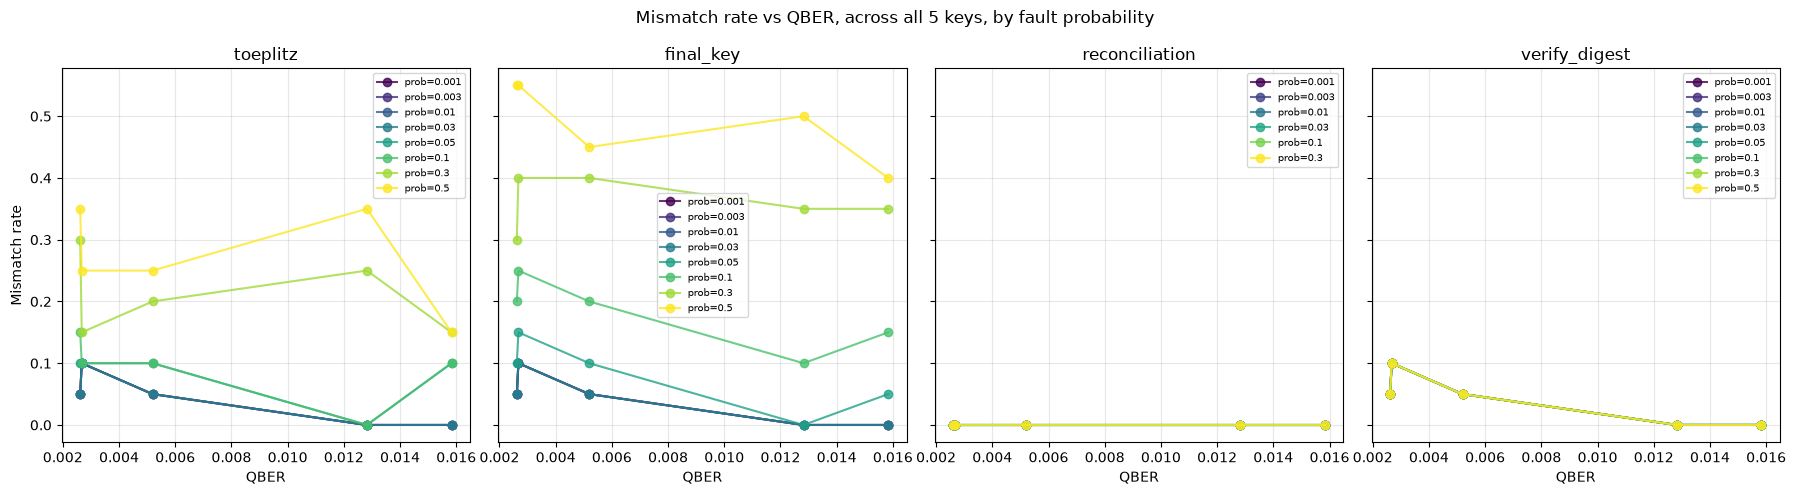

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fault_types = real_df["fault_type"].unique()
fig, axes = plt.subplots(1, len(fault_types), figsize=(18, 5), sharey=True)

for i, fault_type in enumerate(fault_types):
    prob_col = "reconciliation_prob" if fault_type == "reconciliation" else "prob"
    sub = real_df[real_df["fault_type"] == fault_type]

    probs_available = sorted(sub[prob_col].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(probs_available)))

    for prob, color in zip(probs_available, colors):
        sub_at_prob = sub[sub[prob_col] == prob]
        per_key = sub_at_prob.groupby("key_index").agg(
            mismatch_rate=("mismatch", "mean"), qber=("qber", "first")
        ).reset_index().sort_values("qber")

        axes[i].plot(per_key["qber"], per_key["mismatch_rate"], "o-",
                       color=color, label=f"prob={prob}", alpha=0.8)

    axes[i].set_title(fault_type)
    axes[i].set_xlabel("QBER")
    axes[i].legend(fontsize=7, loc="best")
    axes[i].grid(alpha=0.3)

axes[0].set_ylabel("Mismatch rate")
plt.suptitle("Mismatch rate vs QBER, across all 5 keys, by fault probability")
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_mismatch_vs_qber.png"), dpi=150)
plt.show()

In [10]:
def is_baseline_reconciliation_failure(row):
    fired = row["faults_fired"]
    fired_empty = (fired == "{}" or fired == {} or (isinstance(fired, str) and fired.strip() == "{}"))
    return fired_empty and row.get("remaining_errors_after_reconciliation", 0) > 0

real_df["is_baseline_failure"] = real_df.apply(is_baseline_reconciliation_failure, axis=1)
print(f"Baseline reconciliation failures found: {real_df['is_baseline_failure'].sum()} / {len(real_df)}")

# Clean dataset for actual fault-effect analysis
real_df_clean = real_df[~real_df["is_baseline_failure"]].copy()

Baseline reconciliation failures found: 196 / 6000


In [11]:
baseline_summary = real_df.groupby("key_index")["is_baseline_failure"].mean()
print("Baseline (fault-free) reconciliation failure rate per key:")
print(baseline_summary)

Baseline (fault-free) reconciliation failure rate per key:
key_index
0    0.000000
1    0.000000
2    0.080000
3    0.043333
4    0.040000
Name: is_baseline_failure, dtype: float64


In [12]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# --- Step 1: identify and filter baseline reconciliation failures.
# Scoped ONLY to toeplitz/final_key -- for reconciliation itself, trials
# where the injected fault didn't fire are legitimate dose-response data,
# not contamination, so they must NOT be filtered the same way. ---

def is_baseline_reconciliation_failure(row):
    if row["fault_type"] not in ("toeplitz", "final_key"):
        return False
    fired = row["faults_fired"]
    fired_empty = (fired == "{}" or fired == {} or
                    (isinstance(fired, str) and fired.strip() == "{}"))
    return fired_empty and row.get("remaining_errors_after_reconciliation", 0) > 0

real_df["is_baseline_failure"] = real_df.apply(is_baseline_reconciliation_failure, axis=1)

print("=== Baseline (fault-free) reconciliation failure rate, per key ===")
print(real_df[real_df["fault_type"].isin(["toeplitz", "final_key"])]
      .groupby("key_index")["is_baseline_failure"].mean())

n_filtered = real_df["is_baseline_failure"].sum()
print(f"\nFiltering {n_filtered} rows ({100*n_filtered/len(real_df):.1f}% of total) out of real_df")

real_df_clean = real_df[~real_df["is_baseline_failure"]].copy()

=== Baseline (fault-free) reconciliation failure rate, per key ===
key_index
0    0.000000
1    0.000000
2    0.087500
3    0.046875
4    0.050000
Name: is_baseline_failure, dtype: float64

Filtering 118 rows (2.0% of total) out of real_df


In [13]:
# --- Step 2: mean mismatch rate + stdev, on CLEAN data ---
def summarize(df, group_cols):
    g = df.groupby(group_cols)["mismatch"]
    return g.agg(mean_mismatch="mean", std_mismatch="std", n="count").reset_index()

real_summary_clean = summarize(real_df_clean, ["fault_type", "length_mode", "prob"])
print("=== REAL (cleaned): mean mismatch rate (stdev) by fault/mode/prob ===")
print(real_summary_clean.to_string(index=False))

=== REAL (cleaned): mean mismatch rate (stdev) by fault/mode/prob ===
    fault_type length_mode  prob  mean_mismatch  std_mismatch   n
     final_key  asymptotic 0.001       0.000000      0.000000  96
     final_key  asymptotic 0.003       0.000000      0.000000  96
     final_key  asymptotic 0.010       0.000000      0.000000  96
     final_key  asymptotic 0.030       0.000000      0.000000  96
     final_key  asymptotic 0.050       0.041667      0.200875  96
     final_key  asymptotic 0.100       0.145833      0.354792  96
     final_key  asymptotic 0.300       0.333333      0.473879  96
     final_key  asymptotic 0.500       0.474227      0.501929  97
     final_key placeholder 0.001       0.000000      0.000000  96
     final_key placeholder 0.003       0.000000      0.000000  96
     final_key placeholder 0.010       0.000000      0.000000  96
     final_key placeholder 0.030       0.000000      0.000000  96
     final_key placeholder 0.050       0.041667      0.200875  96
     f

In [14]:
# --- Step 3: real (clean) vs mock, two-proportion z-test ---
def two_proportion_ztest(successes1, n1, successes2, n2):
    p1, p2 = successes1 / n1, successes2 / n2
    p_pool = (successes1 + successes2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    if se == 0:
        return np.nan, np.nan
    z = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value

print("=== Real (cleaned) vs Mock: two-proportion z-test ===")
for (fault_type, length_mode, prob), real_g in real_df_clean.groupby(["fault_type", "length_mode", "prob"]):
    mock_g = mock_df[(mock_df["fault_type"] == fault_type) &
                       (mock_df["length_mode"] == length_mode) &
                       (mock_df["prob"] == prob)]
    if len(mock_g) == 0:
        continue
    s1, n1 = real_g["mismatch"].sum(), len(real_g)
    s2, n2 = mock_g["mismatch"].sum(), len(mock_g)
    z, p = two_proportion_ztest(s1, n1, s2, n2)
    sig = "**" if p < 0.05 else ""
    print(f"  {fault_type:<15} {length_mode:<12} prob={prob:<6}: "
          f"real={s1}/{n1}, mock={s2}/{n2}, z={z:.3f}, p={p:.4f} {sig}")

=== Real (cleaned) vs Mock: two-proportion z-test ===
  final_key       asymptotic   prob=0.001 : real=0/96, mock=6/100, z=-2.438, p=0.0148 **
  final_key       asymptotic   prob=0.003 : real=0/96, mock=6/100, z=-2.438, p=0.0148 **
  final_key       asymptotic   prob=0.01  : real=0/96, mock=6/100, z=-2.438, p=0.0148 **
  final_key       asymptotic   prob=0.03  : real=0/96, mock=6/100, z=-2.438, p=0.0148 **
  final_key       asymptotic   prob=0.05  : real=4/96, mock=10/100, z=-1.585, p=0.1129 
  final_key       asymptotic   prob=0.1   : real=14/96, mock=19/100, z=-0.826, p=0.4088 
  final_key       asymptotic   prob=0.3   : real=32/96, mock=37/100, z=-0.537, p=0.5911 
  final_key       asymptotic   prob=0.5   : real=46/97, mock=49/100, z=-0.222, p=0.8247 
  final_key       placeholder  prob=0.001 : real=0/96, mock=6/100, z=-2.438, p=0.0148 **
  final_key       placeholder  prob=0.003 : real=0/96, mock=6/100, z=-2.438, p=0.0148 **
  final_key       placeholder  prob=0.01  : real=0/96, mo

In [15]:
# --- Step 3: real (clean) vs mock, two-proportion z-test ---
def two_proportion_ztest(successes1, n1, successes2, n2):
    p1, p2 = successes1 / n1, successes2 / n2
    p_pool = (successes1 + successes2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    if se == 0:
        return np.nan, np.nan
    z = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value

print("=== Real (cleaned) vs Mock: two-proportion z-test ===")
for (fault_type, length_mode, prob), real_g in real_df_clean.groupby(["fault_type", "length_mode", "prob"]):
    mock_g = mock_df[(mock_df["fault_type"] == fault_type) &
                       (mock_df["length_mode"] == length_mode) &
                       (mock_df["prob"] == prob)]
    if len(mock_g) == 0:
        continue
    s1, n1 = real_g["mismatch"].sum(), len(real_g)
    s2, n2 = mock_g["mismatch"].sum(), len(mock_g)
    z, p = two_proportion_ztest(s1, n1, s2, n2)
    sig = "**" if p < 0.05 else ""
    print(f"  {fault_type:<15} {length_mode:<12} prob={prob:<6}: "
          f"real={s1}/{n1}, mock={s2}/{n2}, z={z:.3f}, p={p:.4f} {sig}")

=== Real (cleaned) vs Mock: two-proportion z-test ===
  final_key       asymptotic   prob=0.001 : real=0/96, mock=6/100, z=-2.438, p=0.0148 **
  final_key       asymptotic   prob=0.003 : real=0/96, mock=6/100, z=-2.438, p=0.0148 **
  final_key       asymptotic   prob=0.01  : real=0/96, mock=6/100, z=-2.438, p=0.0148 **
  final_key       asymptotic   prob=0.03  : real=0/96, mock=6/100, z=-2.438, p=0.0148 **
  final_key       asymptotic   prob=0.05  : real=4/96, mock=10/100, z=-1.585, p=0.1129 
  final_key       asymptotic   prob=0.1   : real=14/96, mock=19/100, z=-0.826, p=0.4088 
  final_key       asymptotic   prob=0.3   : real=32/96, mock=37/100, z=-0.537, p=0.5911 
  final_key       asymptotic   prob=0.5   : real=46/97, mock=49/100, z=-0.222, p=0.8247 
  final_key       placeholder  prob=0.001 : real=0/96, mock=6/100, z=-2.438, p=0.0148 **
  final_key       placeholder  prob=0.003 : real=0/96, mock=6/100, z=-2.438, p=0.0148 **
  final_key       placeholder  prob=0.01  : real=0/96, mo

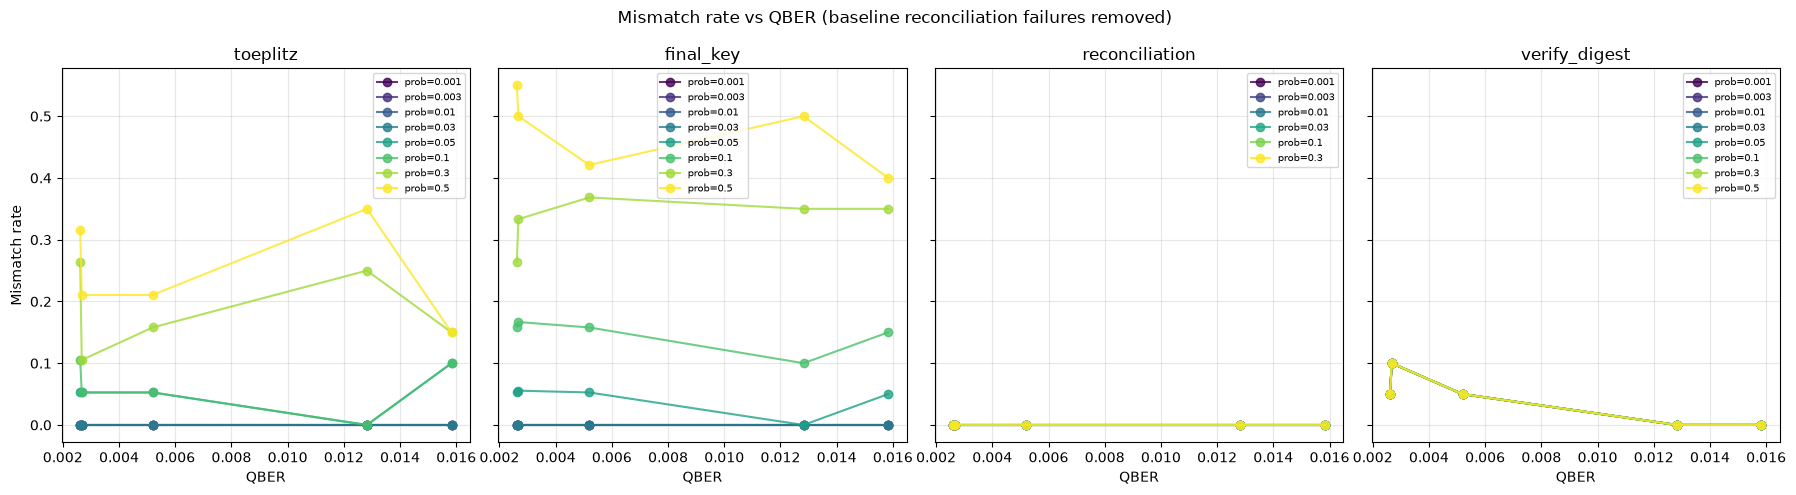

In [16]:
# --- Step 5: mismatch vs QBER, on CLEAN data ---
fault_types = real_df_clean["fault_type"].unique()
fig, axes = plt.subplots(1, len(fault_types), figsize=(18, 5), sharey=True)

for i, fault_type in enumerate(fault_types):
    prob_col = "reconciliation_prob" if fault_type == "reconciliation" else "prob"
    sub = real_df_clean[real_df_clean["fault_type"] == fault_type]

    probs_available = sorted(sub[prob_col].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(probs_available)))

    for prob, color in zip(probs_available, colors):
        sub_at_prob = sub[sub[prob_col] == prob]
        per_key = sub_at_prob.groupby("key_index").agg(
            mismatch_rate=("mismatch", "mean"), qber=("qber", "first")
        ).reset_index().sort_values("qber")
        axes[i].plot(per_key["qber"], per_key["mismatch_rate"], "o-",
                       color=color, label=f"prob={prob}", alpha=0.8)

    axes[i].set_title(fault_type)
    axes[i].set_xlabel("QBER")
    axes[i].legend(fontsize=7, loc="best")
    axes[i].grid(alpha=0.3)

axes[0].set_ylabel("Mismatch rate")
plt.suptitle("Mismatch rate vs QBER (baseline reconciliation failures removed)")
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_mismatch_vs_qber_clean.png"), dpi=150)
plt.show()

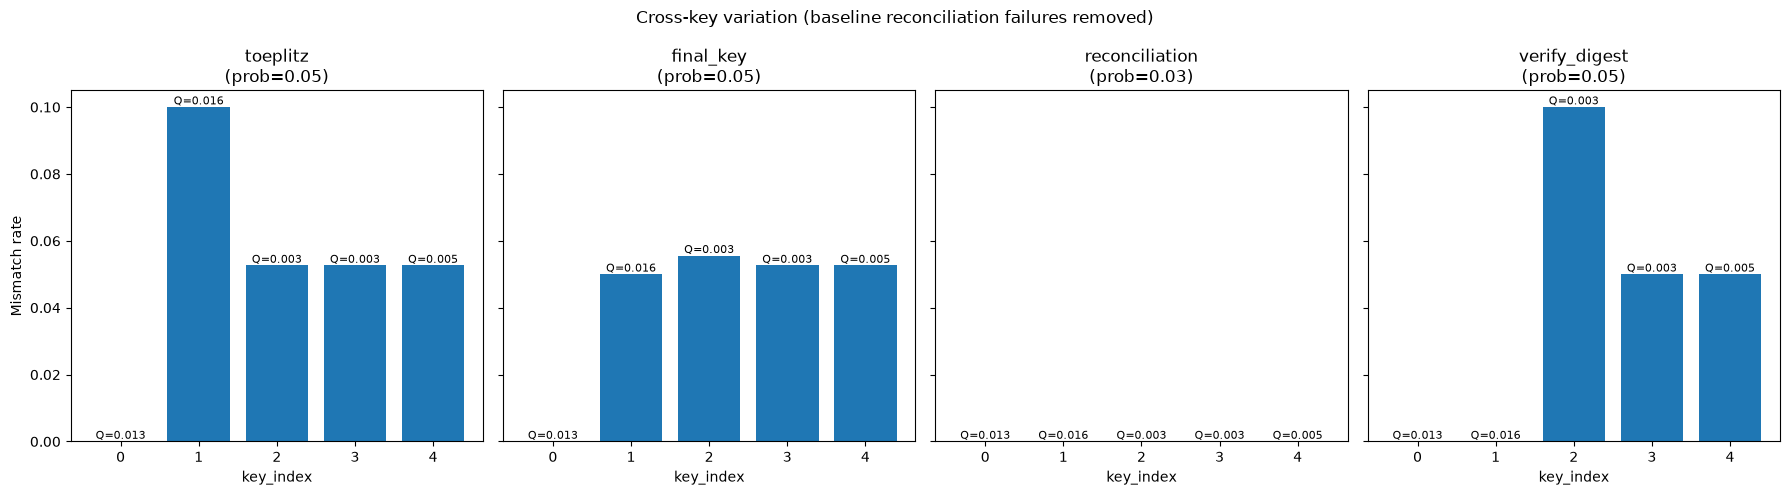

In [17]:
# --- Step 6: cross-key variation, on CLEAN data ---
fig, axes = plt.subplots(1, len(fault_types), figsize=(18, 5), sharey=True)

for i, fault_type in enumerate(fault_types):
    prob_col = "reconciliation_prob" if fault_type == "reconciliation" else "prob"
    sub = real_df_clean[real_df_clean["fault_type"] == fault_type]

    probs_available = sorted(sub[prob_col].unique())
    mid_prob = probs_available[len(probs_available) // 2]
    sub_at_prob = sub[sub[prob_col] == mid_prob]

    per_key = sub_at_prob.groupby("key_index").agg(
        mismatch_rate=("mismatch", "mean"), qber=("qber", "first")
    ).reset_index()

    axes[i].bar(per_key["key_index"].astype(str), per_key["mismatch_rate"])
    axes[i].set_title(f"{fault_type}\n(prob={mid_prob})")
    axes[i].set_xlabel("key_index")
    for _, row in per_key.iterrows():
        axes[i].annotate(f"Q={row['qber']:.3f}", (str(int(row['key_index'])), row['mismatch_rate']),
                            ha='center', va='bottom', fontsize=8)

axes[0].set_ylabel("Mismatch rate")
plt.suptitle("Cross-key variation (baseline reconciliation failures removed)")
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_crosskey_variation_clean.png"), dpi=150)
plt.show()

In [18]:
real_df_clean["recon_outcome"] = (
    real_df_clean["non_convergent"].fillna(False) |
    (real_df_clean["verification_passed"] == False)
)

print("=== Reconciliation outcome rate (real, cleaned, using recon_outcome not mismatch) ===")
print(real_df_clean[real_df_clean["fault_type"] == "reconciliation"]
      .groupby(["length_mode", "prob"])["recon_outcome"].agg(["mean", "std", "count"]))

=== Reconciliation outcome rate (real, cleaned, using recon_outcome not mismatch) ===
                   mean       std  count
length_mode prob                        
asymptotic  0.001  0.04  0.196946    100
            0.003  0.09  0.287623    100
            0.010  0.29  0.456048    100
            0.030  0.82  0.386123    100
            0.100  1.00  0.000000    100
            0.300  1.00  0.000000    100
placeholder 0.001  0.04  0.196946    100
            0.003  0.09  0.287623    100
            0.010  0.29  0.456048    100
            0.030  0.82  0.386123    100
            0.100  1.00  0.000000    100
            0.300  1.00  0.000000    100


In [19]:
mock_recon_cols = mock_df[mock_df["fault_type"] == "reconciliation"].columns.tolist()
print(mock_recon_cols)

['toeplitz_prob', 'final_key_prob', 'reconciliation_prob', 'verify_digest_prob', 'qber_after_reconciliation', 'secure_key_length', 't_verify', 'verification_passed', 'keys_match', 'n_mismatched_bits', 'elapsed_seconds', 'faults_fired', 'non_convergent', 'error', 'condition', 'run', 'fault_type', 'prob', 'length_mode', 'key_index', 'qber', 'source', 'mismatch', 'true_abort', 'false_abort', 'abort']


In [20]:
mock_baseline_check = mock_df[(mock_df["fault_type"].isin(["toeplitz", "final_key"])) &
                                 (mock_df["prob"].isin([0.001, 0.003, 0.01, 0.03])) &
                                 (mock_df["mismatch"] == True)]
print(mock_baseline_check[["fault_type", "prob", "key_index", "faults_fired",
                              "qber_after_reconciliation"]].drop_duplicates())

     fault_type   prob  key_index faults_fired  qber_after_reconciliation
1842   toeplitz  0.030          2           {}                   0.000595
1862   toeplitz  0.010          2           {}                   0.000595
1882   toeplitz  0.003          2           {}                   0.000595
1902   toeplitz  0.001          2           {}                   0.000595
2002  final_key  0.030          2           {}                   0.000595
2022  final_key  0.010          2           {}                   0.000595
2042  final_key  0.003          2           {}                   0.000595
2062  final_key  0.001          2           {}                   0.000595
2726   toeplitz  0.030          3           {}                   0.000583
2728   toeplitz  0.030          3           {}                   0.001749
2734   toeplitz  0.030          3           {}                   0.002332
2746   toeplitz  0.010          3           {}                   0.000583
2748   toeplitz  0.010          3     

In [22]:
def is_baseline_reconciliation_failure_mock(row):
    if row["fault_type"] not in ("toeplitz", "final_key"):
        return False
    fired = row["faults_fired"]
    fired_empty = (fired == "{}" or fired == {} or
                    (isinstance(fired, str) and fired.strip() == "{}"))
    return fired_empty and row.get("qber_after_reconciliation", 0) > 0

mock_df["is_baseline_failure"] = mock_df.apply(is_baseline_reconciliation_failure_mock, axis=1)
print(f"Mock baseline failures: {mock_df['is_baseline_failure'].sum()} / {len(mock_df)}")

mock_df_clean = mock_df[~mock_df["is_baseline_failure"]].copy()

Mock baseline failures: 162 / 4400


In [23]:
print(mock_df[mock_df["fault_type"] == "reconciliation"]["keys_match"].value_counts(dropna=False))

keys_match
False    650
True     550
Name: count, dtype: int64


In [24]:
mock_df_clean = mock_df[~mock_df["is_baseline_failure"]].copy()

mock_df_clean["recon_outcome"] = (
    mock_df_clean["non_convergent"].fillna(False) |
    (mock_df_clean["verification_passed"] == False)
)

print("=== Real (cleaned) vs Mock (cleaned): recon_outcome, both computed identically ===")
for prob in [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]:
    real_g = real_df_clean[(real_df_clean["fault_type"] == "reconciliation") &
                              (real_df_clean["prob"] == prob)]
    mock_g = mock_df_clean[(mock_df_clean["fault_type"] == "reconciliation") &
                              (mock_df_clean["prob"] == prob)]
    if len(real_g) == 0 or len(mock_g) == 0:
        continue
    s1, n1 = real_g["recon_outcome"].sum(), len(real_g)
    s2, n2 = mock_g["recon_outcome"].sum(), len(mock_g)
    z, p = two_proportion_ztest(s1, n1, s2, n2)
    sig = "**" if p < 0.05 else ""
    print(f"  prob={prob:<6}: real={s1}/{n1} ({s1/n1:.2f}), mock={s2}/{n2} ({s2/n2:.2f}), "
          f"z={z:.3f}, p={p:.4f} {sig}")

=== Real (cleaned) vs Mock (cleaned): recon_outcome, both computed identically ===
  prob=0.001 : real=8/200 (0.04), mock=12/200 (0.06), z=-0.918, p=0.3588 
  prob=0.003 : real=18/200 (0.09), mock=22/200 (0.11), z=-0.667, p=0.5050 
  prob=0.01  : real=58/200 (0.29), mock=54/200 (0.27), z=0.445, p=0.6560 
  prob=0.03  : real=164/200 (0.82), mock=162/200 (0.81), z=0.258, p=0.7968 
  prob=0.1   : real=200/200 (1.00), mock=200/200 (1.00), z=nan, p=nan 
  prob=0.3   : real=200/200 (1.00), mock=200/200 (1.00), z=nan, p=nan 


In [25]:
print("=== Real (cleaned) vs Mock (cleaned): toeplitz/final_key/verify_digest ===")
for (fault_type, length_mode, prob), real_g in real_df_clean.groupby(["fault_type", "length_mode", "prob"]):
    if fault_type == "reconciliation":
        continue  # handled separately above, using recon_outcome not mismatch
    mock_g = mock_df_clean[(mock_df_clean["fault_type"] == fault_type) &
                              (mock_df_clean["length_mode"] == length_mode) &
                              (mock_df_clean["prob"] == prob)]
    if len(mock_g) == 0:
        continue
    s1, n1 = real_g["mismatch"].sum(), len(real_g)
    s2, n2 = mock_g["mismatch"].sum(), len(mock_g)
    z, p = two_proportion_ztest(s1, n1, s2, n2)
    sig = "**" if p < 0.05 else ""
    print(f"  {fault_type:<15} {length_mode:<12} prob={prob:<6}: "
          f"real={s1}/{n1}, mock={s2}/{n2}, z={z:.3f}, p={p:.4f} {sig}")

=== Real (cleaned) vs Mock (cleaned): toeplitz/final_key/verify_digest ===
  final_key       asymptotic   prob=0.001 : real=0/96, mock=0/94, z=nan, p=nan 
  final_key       asymptotic   prob=0.003 : real=0/96, mock=0/94, z=nan, p=nan 
  final_key       asymptotic   prob=0.01  : real=0/96, mock=0/94, z=nan, p=nan 
  final_key       asymptotic   prob=0.03  : real=0/96, mock=0/94, z=nan, p=nan 
  final_key       asymptotic   prob=0.05  : real=4/96, mock=6/96, z=-0.650, p=0.5160 
  final_key       asymptotic   prob=0.1   : real=14/96, mock=15/96, z=-0.202, p=0.8403 
  final_key       asymptotic   prob=0.3   : real=32/96, mock=33/96, z=-0.153, p=0.8788 
  final_key       asymptotic   prob=0.5   : real=46/97, mock=47/98, z=-0.075, p=0.9402 
  final_key       placeholder  prob=0.001 : real=0/96, mock=0/94, z=nan, p=nan 
  final_key       placeholder  prob=0.003 : real=0/96, mock=0/94, z=nan, p=nan 
  final_key       placeholder  prob=0.01  : real=0/96, mock=0/94, z=nan, p=nan 
  final_key    

In [26]:
print(mock_df_clean[mock_df_clean["fault_type"] == "verify_digest"]["length_mode"].unique())
print(real_df_clean[real_df_clean["fault_type"] == "verify_digest"]["length_mode"].unique())

<StringArray>
[]
Length: 0, dtype: str
<StringArray>
['placeholder', 'asymptotic']
Length: 2, dtype: str
